# 🧠 Alzheimer's Disease Diagnosis — Machine Learning Pipeline

This notebook builds an end-to-end ML pipeline to predict whether a patient has Alzheimer's Disease
based on demographic, lifestyle, medical history, clinical, and cognitive features.

**Target variable:** `Diagnosis` (0 = No Alzheimer's, 1 = Alzheimer's)


In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
})

print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 1. Load & Preview Data

In [2]:
df = pd.read_csv("alzheimers_disease_data.csv")

# Drop non-predictive columns
df.drop(columns=["PatientID", "DoctorInCharge"], inplace=True)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape: 2,149 rows × 33 columns


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("=== Data Types & Non-Null Counts ===")
df.info()
print()
print("=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values total")
print()
print("=== Statistical Summary ===")
df.describe().round(2)


=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression            

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.00,2149.00,2149.0,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,...,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00
mean,74.91,0.51,0.7,1.29,27.66,0.29,10.04,4.92,4.99,7.05,...,5.08,0.21,0.16,4.98,0.21,0.16,0.15,0.16,0.30,0.35
std,8.99,0.50,1.0,0.90,7.22,0.45,5.76,2.86,2.91,1.76,...,2.89,0.41,0.36,2.95,0.40,0.37,0.36,0.37,0.46,0.48
min,60.00,0.00,0.0,0.00,15.01,0.00,0.00,0.00,0.01,4.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,67.00,0.00,0.0,1.00,21.61,0.00,5.14,2.57,2.46,5.48,...,2.57,0.00,0.00,2.34,0.00,0.00,0.00,0.00,0.00,0.00
50%,75.00,1.00,0.0,1.00,27.82,0.00,9.93,4.77,5.08,7.12,...,5.09,0.00,0.00,5.04,0.00,0.00,0.00,0.00,0.00,0.00
75%,83.00,1.00,1.0,2.00,33.87,1.00,15.16,7.43,7.56,8.56,...,7.55,0.00,0.00,7.58,0.00,0.00,0.00,0.00,1.00,1.00
max,90.00,1.00,3.0,3.00,39.99,1.00,19.99,9.99,10.00,10.00,...,10.00,1.00,1.00,10.00,1.00,1.00,1.00,1.00,1.00,1.00


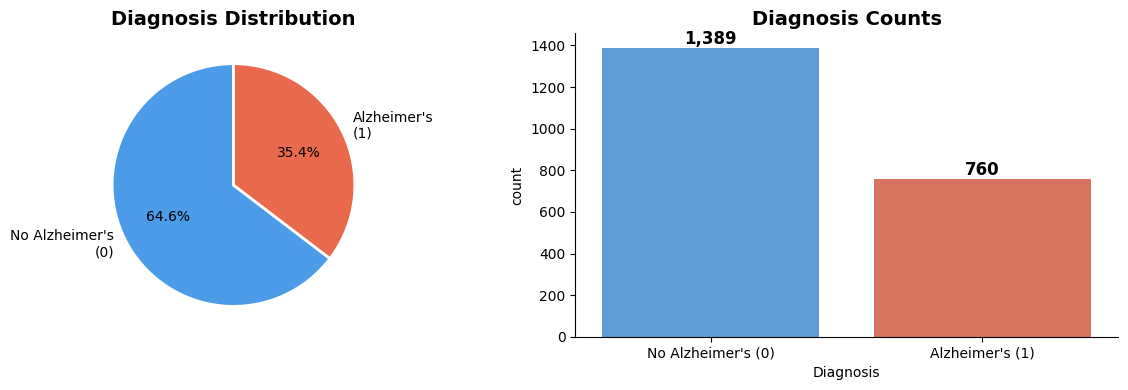

Class ratio  →  0 (No): 1,389  |  1 (Yes): 760


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df["Diagnosis"].value_counts()
axes[0].pie(counts, labels=["No Alzheimer's\n(0)", "Alzheimer's\n(1)"],
            autopct="%1.1f%%", colors=["#4C9BE8", "#E8694C"],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Diagnosis Distribution", fontsize=14, fontweight="bold")

# Count plot
sns.countplot(data=df, x="Diagnosis", palette=["#4C9BE8", "#E8694C"], ax=axes[1])
axes[1].set_xticklabels(["No Alzheimer's (0)", "Alzheimer's (1)"])
axes[1].set_title("Diagnosis Counts", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Diagnosis")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Class ratio  →  0 (No): {counts[0]:,}  |  1 (Yes): {counts[1]:,}")


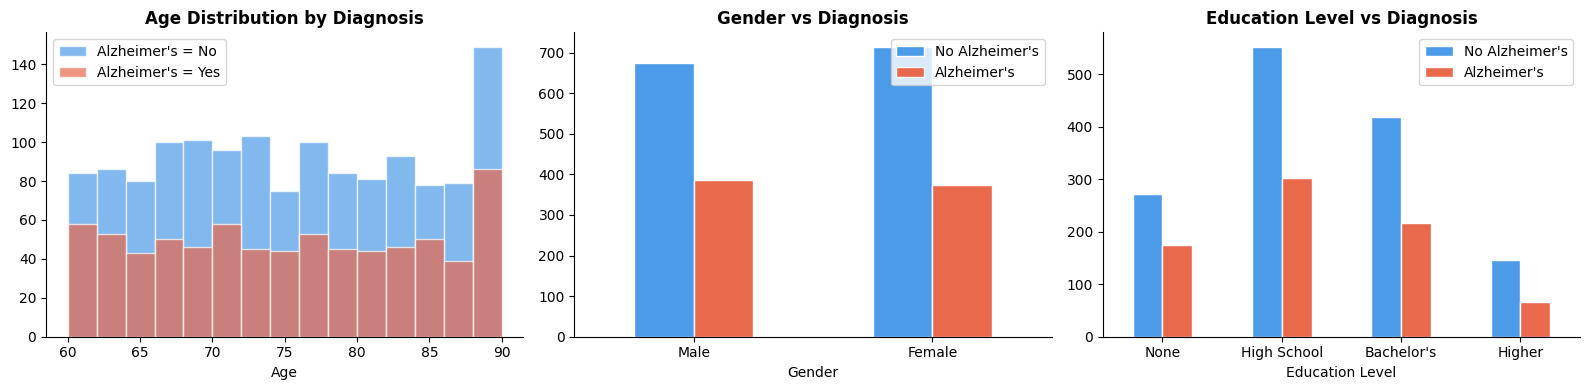

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution by diagnosis
for diag, color, label in [(0, "#4C9BE8", "No"), (1, "#E8694C", "Yes")]:
    subset = df[df["Diagnosis"] == diag]["Age"]
    axes[0].hist(subset, bins=15, alpha=0.7, color=color, label=f"Alzheimer's = {label}", edgecolor="white")
axes[0].set_title("Age Distribution by Diagnosis", fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].legend()

# Gender vs Diagnosis
gender_diag = df.groupby(["Gender", "Diagnosis"]).size().unstack()
gender_diag.index = ["Male", "Female"]
gender_diag.plot(kind="bar", ax=axes[1], color=["#4C9BE8", "#E8694C"], edgecolor="white", rot=0)
axes[1].set_title("Gender vs Diagnosis", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].legend(["No Alzheimer's", "Alzheimer's"])

# Education Level vs Diagnosis
edu_diag = df.groupby(["EducationLevel", "Diagnosis"]).size().unstack()
edu_diag.index = ["None", "High School", "Bachelor's", "Higher"]
edu_diag.plot(kind="bar", ax=axes[2], color=["#4C9BE8", "#E8694C"], edgecolor="white", rot=0)
axes[2].set_title("Education Level vs Diagnosis", fontweight="bold")
axes[2].set_xlabel("Education Level")
axes[2].legend(["No Alzheimer's", "Alzheimer's"])

plt.tight_layout()
plt.savefig("demographic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


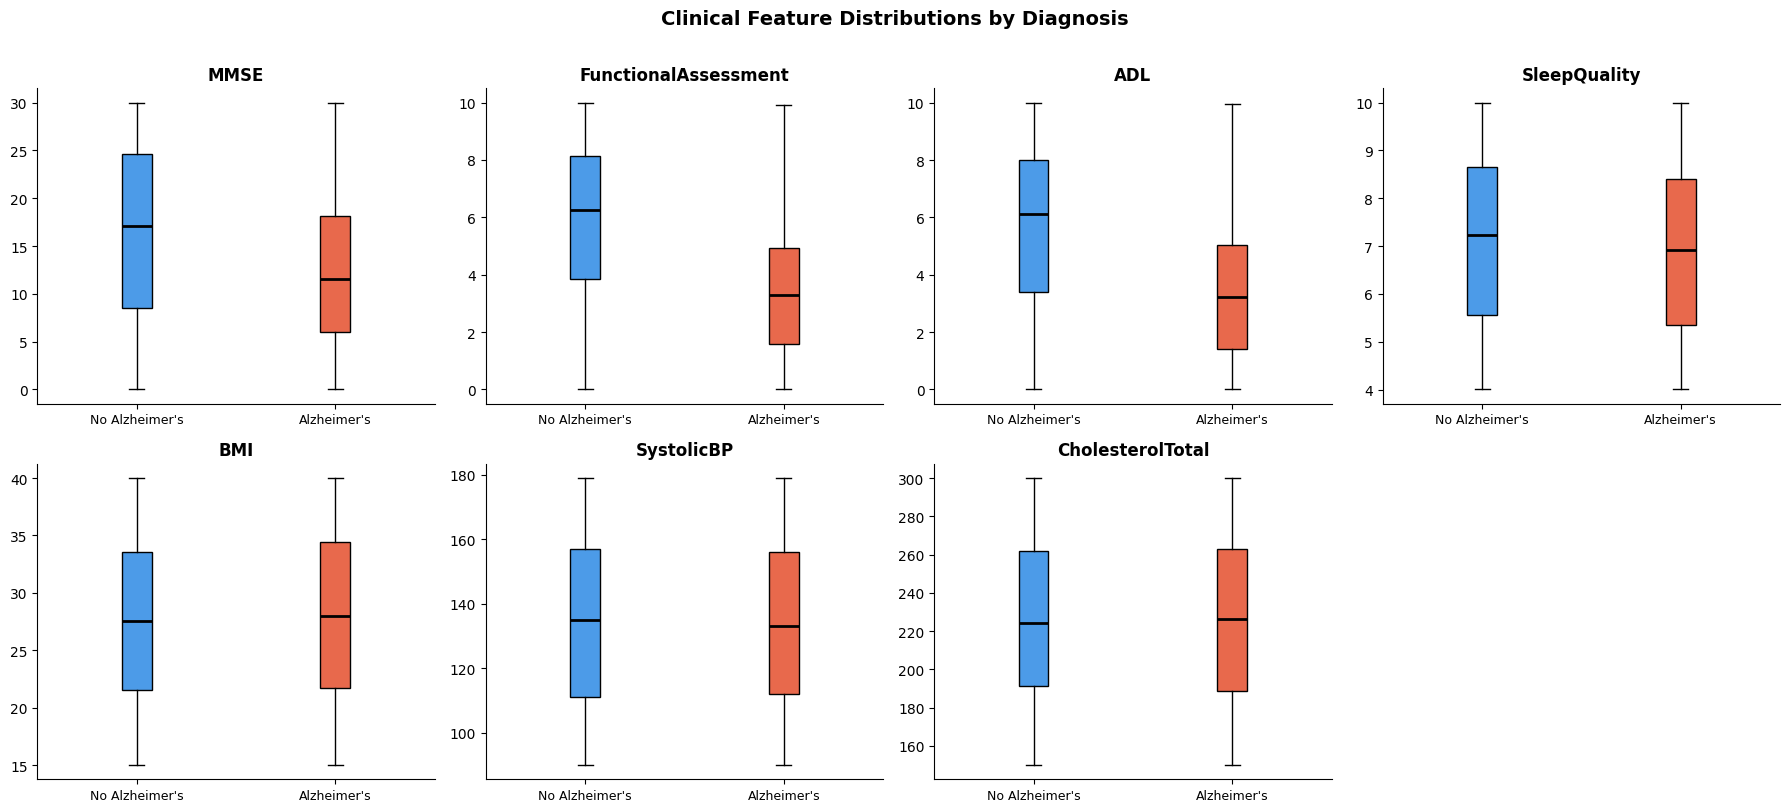

In [6]:
# Box plots for key continuous features split by diagnosis
continuous_features = ["MMSE", "FunctionalAssessment", "ADL",
                        "SleepQuality", "BMI", "SystolicBP", "CholesterolTotal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    data_0 = df[df["Diagnosis"] == 0][feat]
    data_1 = df[df["Diagnosis"] == 1][feat]
    bp = axes[i].boxplot([data_0, data_1], patch_artist=True,
                          medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#4C9BE8")
    bp["boxes"][1].set_facecolor("#E8694C")
    axes[i].set_xticklabels(["No Alzheimer's", "Alzheimer's"])
    axes[i].set_title(feat, fontweight="bold")
    axes[i].tick_params(axis="x", labelsize=9)

axes[-1].axis("off")
plt.suptitle("Clinical Feature Distributions by Diagnosis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("clinical_features.png", dpi=150, bbox_inches="tight")
plt.show()


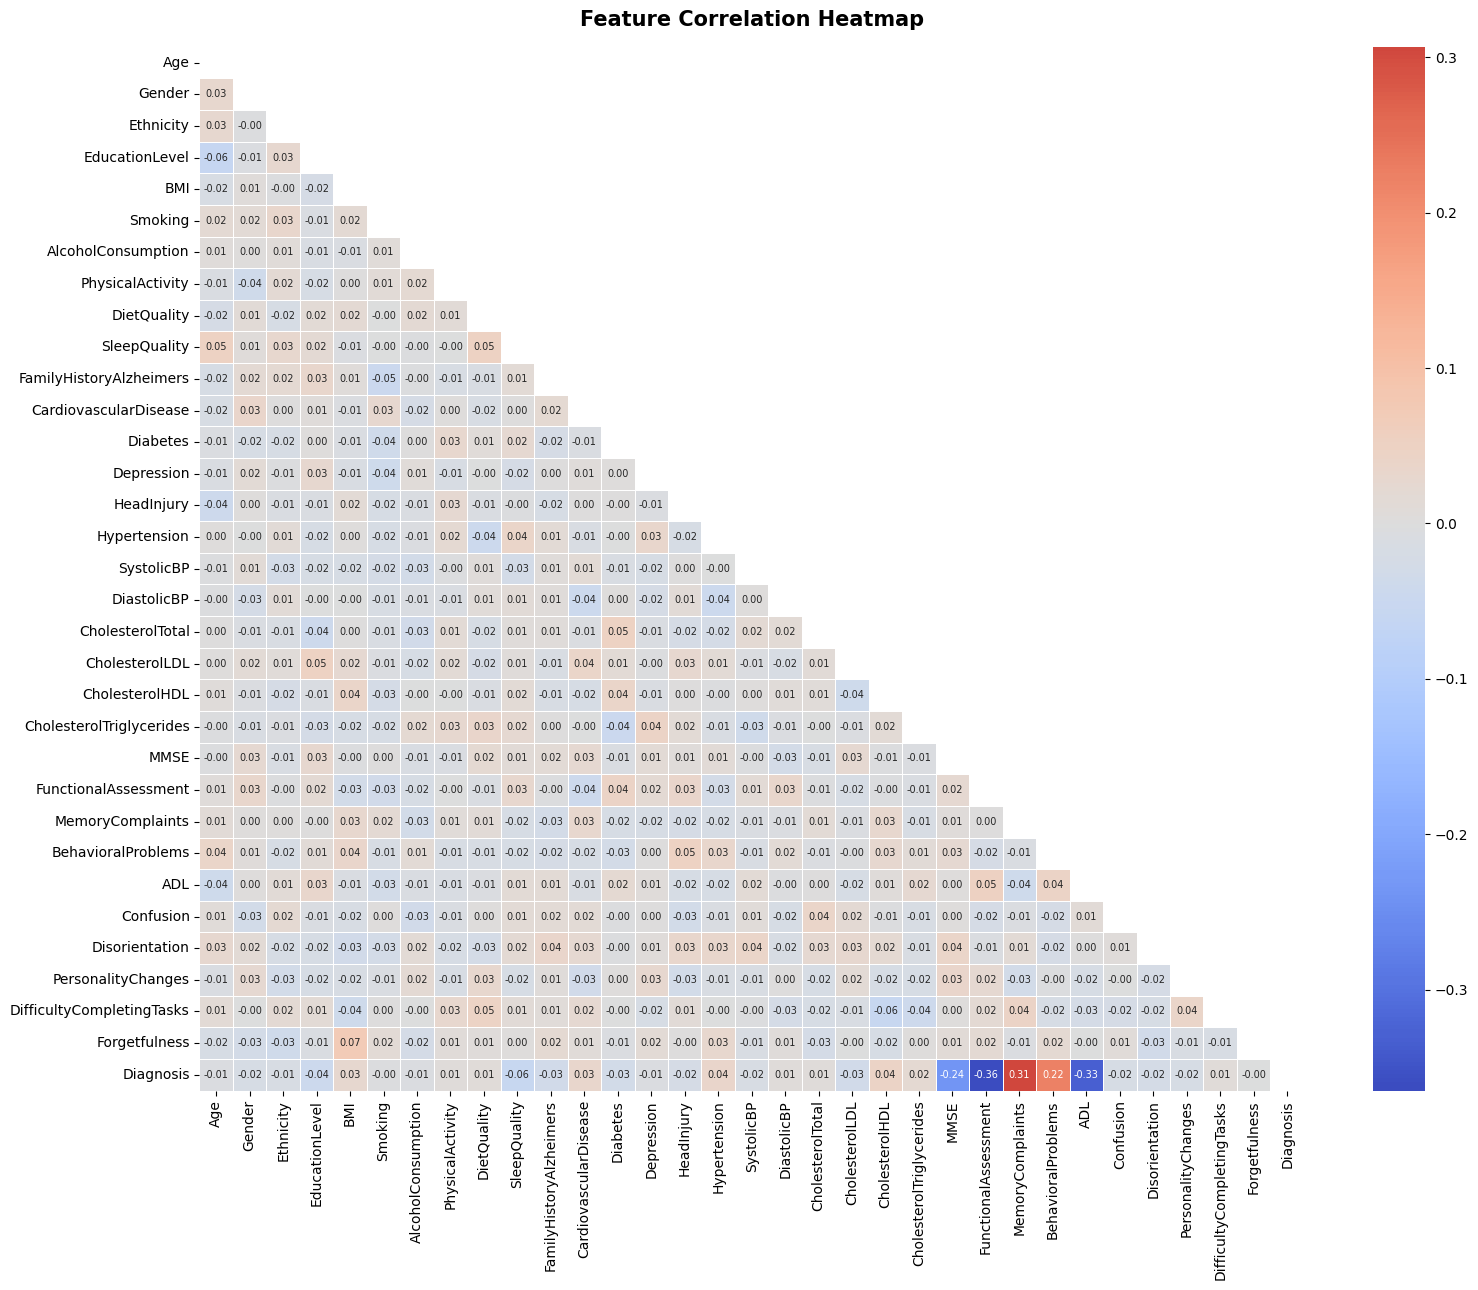

In [7]:
fig, ax = plt.subplots(figsize=(16, 13))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", linewidths=0.4,
            cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Heatmap", fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


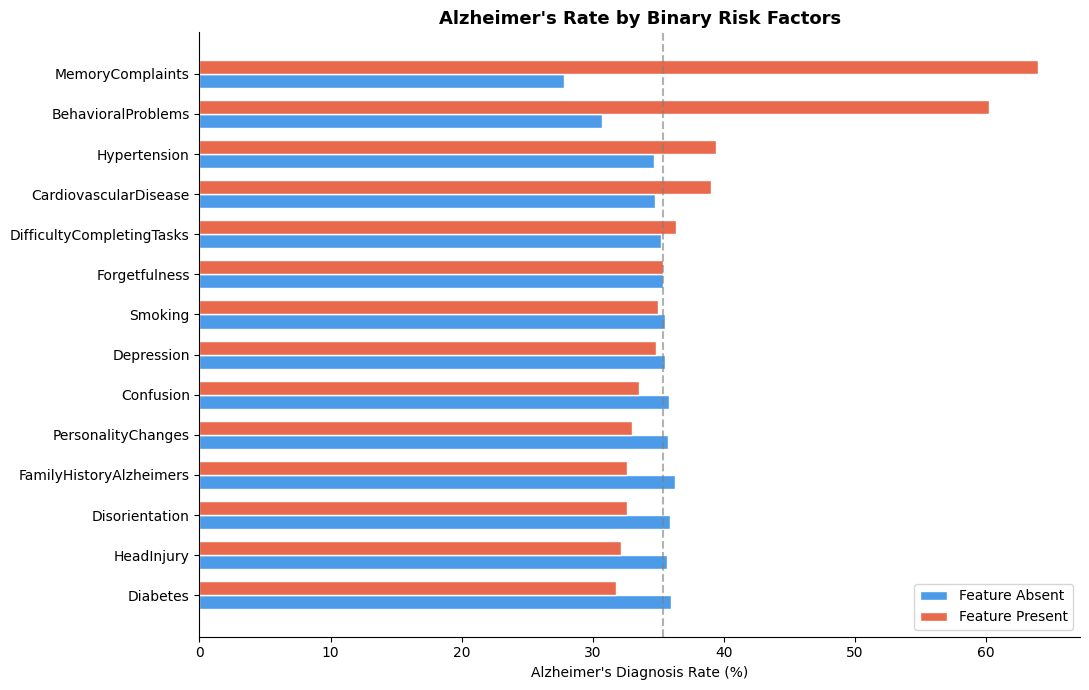

In [8]:
binary_features = [
    "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
    "Diabetes", "Depression", "HeadInjury", "Hypertension",
    "MemoryComplaints", "BehavioralProblems", "Confusion",
    "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"
]

# Calculate Alzheimer's rate for each binary feature
rates = {}
for feat in binary_features:
    rate_0 = df[df[feat] == 0]["Diagnosis"].mean() * 100
    rate_1 = df[df[feat] == 1]["Diagnosis"].mean() * 100
    rates[feat] = {"Without": rate_0, "With": rate_1}

rates_df = pd.DataFrame(rates).T.sort_values("With", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(rates_df))
width = 0.35
ax.barh(x - width/2, rates_df["Without"], width, label="Feature Absent", color="#4C9BE8", edgecolor="white")
ax.barh(x + width/2, rates_df["With"],    width, label="Feature Present", color="#E8694C", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(rates_df.index)
ax.set_xlabel("Alzheimer's Diagnosis Rate (%)")
ax.set_title("Alzheimer's Rate by Binary Risk Factors", fontweight="bold", fontsize=13)
ax.legend()
ax.axvline(df["Diagnosis"].mean() * 100, color="gray", linestyle="--", alpha=0.6, label="Overall rate")
plt.tight_layout()
plt.savefig("binary_feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"Features     : {X_train.shape[1]}")
print(f"Train class balance → 0: {(y_train==0).sum()}  |  1: {(y_train==1).sum()}")
print(f"Test  class balance → 0: {(y_test==0).sum()}  |  1: {(y_test==1).sum()}")


Training set : 1,719 samples
Test set     : 430 samples
Features     : 32
Train class balance → 0: 1111  |  1: 608
Test  class balance → 0: 278  |  1: 152


## 4. Model Training

In [10]:
scaler = StandardScaler()

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    KNeighborsClassifier(n_neighbors=7))
    ]),
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(probability=True, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    ),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                 scoring="roc_auc", n_jobs=-1)
    results[name] = {
        "model":      model,
        "y_pred":     y_pred,
        "y_proba":    y_proba,
        "accuracy":   (y_pred == y_test).mean(),
        "roc_auc":    roc_auc_score(y_test, y_proba),
        "cv_mean":    cv_scores.mean(),
        "cv_std":     cv_scores.std(),
        "report":     classification_report(y_test, y_pred, output_dict=True),
    }
    print(f"✅  {name:<26}  Acc: {results[name]['accuracy']:.3f}  "
          f"AUC: {results[name]['roc_auc']:.3f}  "
          f"CV-AUC: {results[name]['cv_mean']:.3f} ± {results[name]['cv_std']:.3f}")


✅  Logistic Regression         Acc: 0.816  AUC: 0.885  CV-AUC: 0.904 ± 0.014
✅  K-Nearest Neighbors         Acc: 0.709  AUC: 0.765  CV-AUC: 0.770 ± 0.020


✅  Support Vector Machine      Acc: 0.835  AUC: 0.896  CV-AUC: 0.894 ± 0.015


✅  Random Forest               Acc: 0.944  AUC: 0.940  CV-AUC: 0.956 ± 0.012


✅  Gradient Boosting           Acc: 0.949  AUC: 0.948  CV-AUC: 0.954 ± 0.015


✅  XGBoost                     Acc: 0.949  AUC: 0.950  CV-AUC: 0.956 ± 0.012


## 5. Model Comparison

In [11]:
summary = pd.DataFrame({
    name: {
        "Accuracy":  v["accuracy"],
        "ROC-AUC":   v["roc_auc"],
        "Precision": v["report"]["weighted avg"]["precision"],
        "Recall":    v["report"]["weighted avg"]["recall"],
        "F1-Score":  v["report"]["weighted avg"]["f1-score"],
        "CV-AUC (mean)": v["cv_mean"],
        "CV-AUC (std)":  v["cv_std"],
    }
    for name, v in results.items()
}).T.round(4)

summary.sort_values("ROC-AUC", ascending=False)


,Accuracy,ROC-AUC,Precision,Recall,F1-Score,CV-AUC (mean),CV-AUC (std)
XGBoost,0.9488,0.9502,0.9488,0.9488,0.9486,0.9557,0.0120
Gradient Boosting,0.9488,0.9481,0.9487,0.9488,0.9488,0.9544,0.0146
Random Forest,0.9442,0.9402,0.9442,0.9442,0.9438,0.9562,0.0123
Support Vector Machine,0.8349,0.8963,0.8329,0.8349,0.8331,0.8945,0.0149
Logistic Regression,0.8163,0.8854,0.8160,0.8163,0.8161,0.9042,0.0142
K-Nearest Neighbors,0.7093,0.7647,0.6981,0.7093,0.6882,0.7704,0.0204


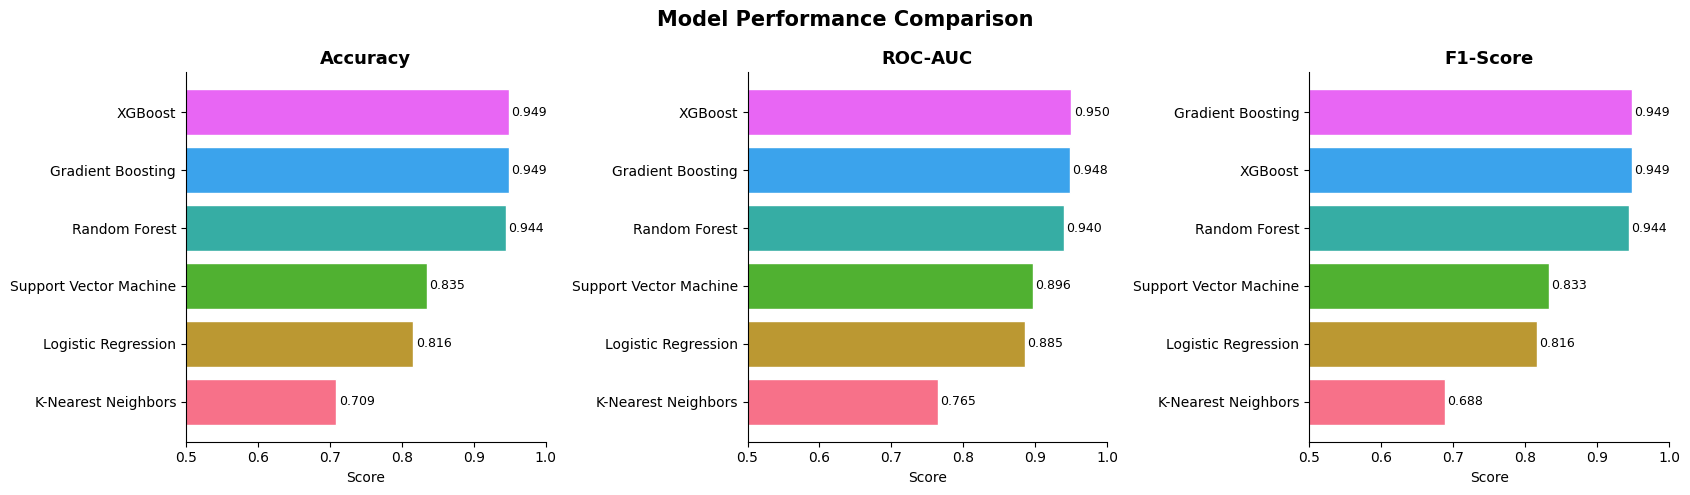

In [12]:
metrics = ["Accuracy", "ROC-AUC", "F1-Score"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette = sns.color_palette("husl", len(summary))

for ax, metric in zip(axes, metrics):
    sorted_df = summary.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df.index, sorted_df[metric], color=palette, edgecolor="white")
    ax.set_xlim(0.5, 1.0)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.set_xlabel("Score")
    for bar in bars:
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.3f}", va="center", fontsize=9)

plt.suptitle("Model Performance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. ROC Curves

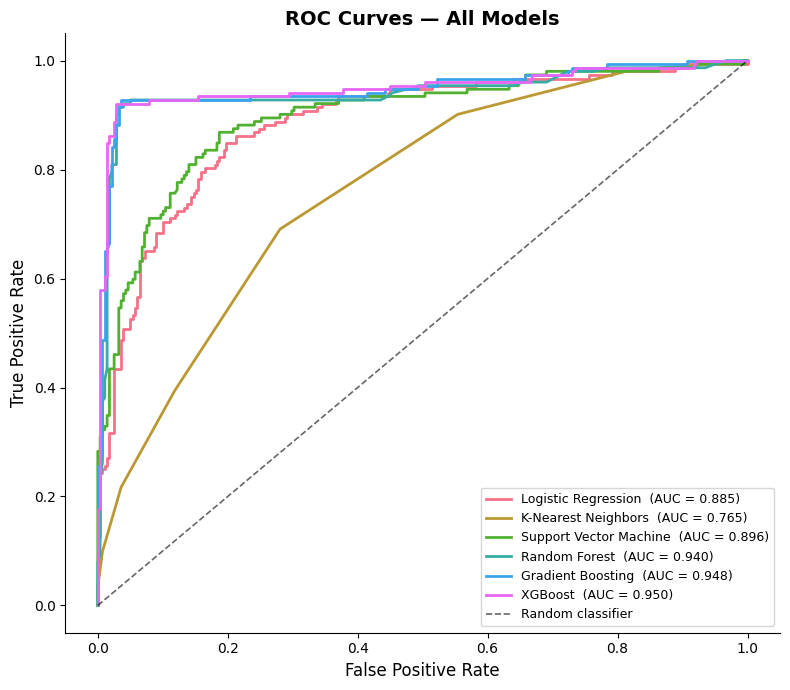

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = sns.color_palette("husl", len(results))

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v["y_proba"])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name}  (AUC = {v['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.6, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Confusion Matrices

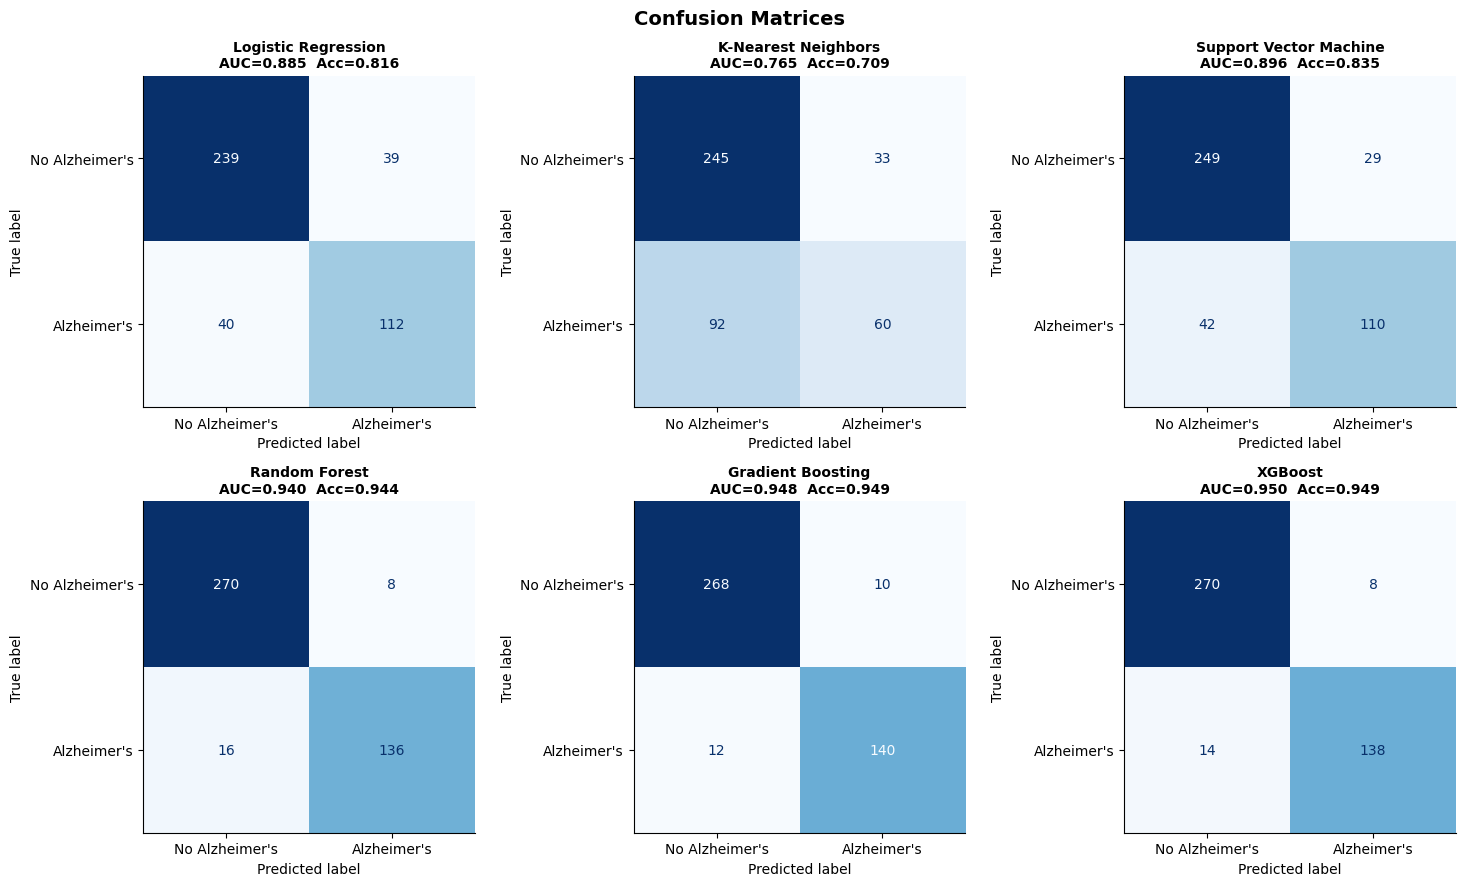

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Alzheimer's", "Alzheimer's"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAUC={v['roc_auc']:.3f}  Acc={v['accuracy']:.3f}",
                 fontsize=10, fontweight="bold")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Feature Importance — Best Model

🏆 Best model: XGBoost  (AUC = 0.9502)


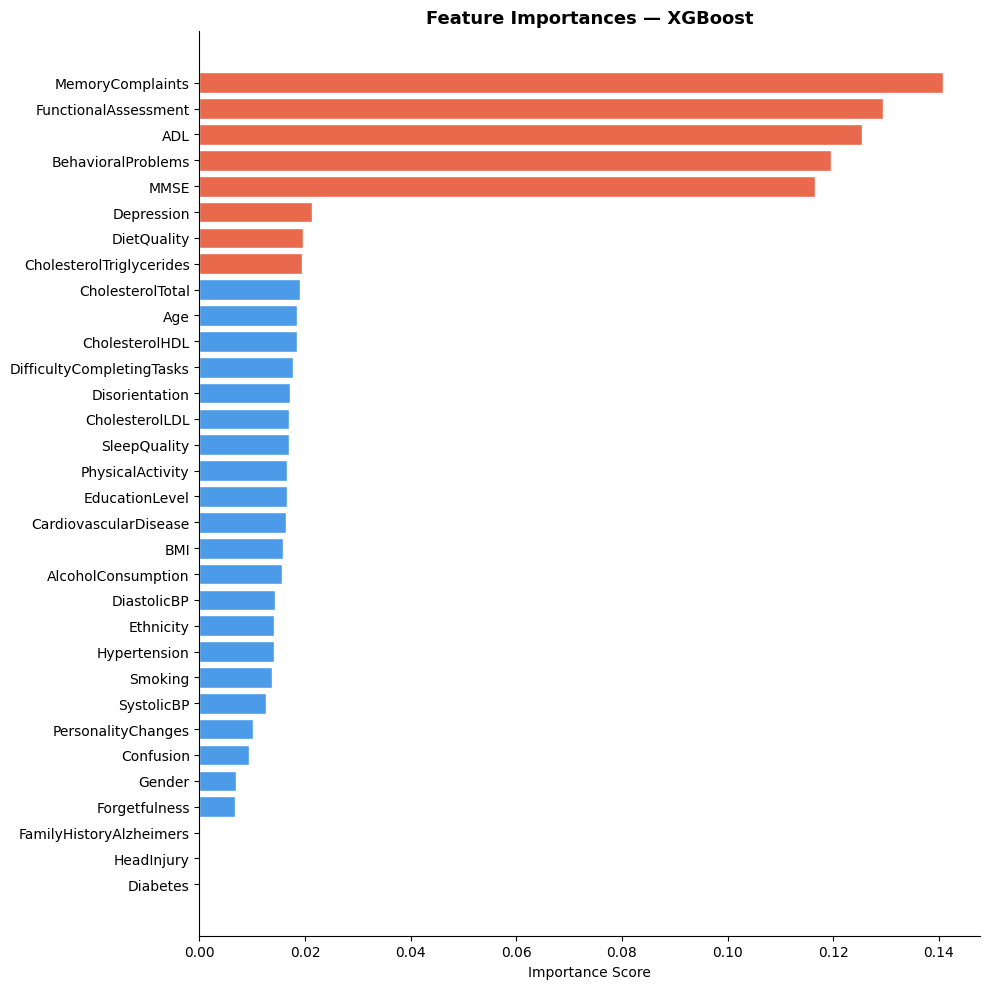


Top 10 most important features:
MemoryComplaints            0.1408
FunctionalAssessment        0.1295
ADL                         0.1254
BehavioralProblems          0.1196
MMSE                        0.1166
Depression                  0.0212
DietQuality                 0.0196
CholesterolTriglycerides    0.0194
CholesterolTotal            0.0191
Age                         0.0185
dtype: float32


In [15]:
# Identify best model by ROC-AUC
best_name = summary["ROC-AUC"].idxmax()
best_model = results[best_name]["model"]
print(f"🏆 Best model: {best_name}  (AUC = {results[best_name]['roc_auc']:.4f})")

# Extract feature importances
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "named_steps"):
    clf = best_model.named_steps["clf"]
    if hasattr(clf, "coef_"):
        importances = np.abs(clf.coef_[0])
    else:
        importances = clf.feature_importances_
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 10))
    colors_imp = ["#E8694C" if v > feat_imp.quantile(0.75) else "#4C9BE8" for v in feat_imp]
    ax.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor="white")
    ax.set_title(f"Feature Importances — {best_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nTop 10 most important features:")
    print(feat_imp.sort_values(ascending=False).head(10).round(4))


## 9. Detailed Classification Report — Best Model

In [16]:
print(f"{'='*55}")
print(f"  Classification Report — {best_name}")
print(f"{'='*55}")
print(classification_report(y_test, results[best_name]["y_pred"],
                             target_names=["No Alzheimer's", "Alzheimer's"]))

print(f"\nROC-AUC Score : {results[best_name]['roc_auc']:.4f}")
print(f"Accuracy      : {results[best_name]['accuracy']:.4f}")


  Classification Report — XGBoost
                precision    recall  f1-score   support

No Alzheimer's       0.95      0.97      0.96       278
   Alzheimer's       0.95      0.91      0.93       152

      accuracy                           0.95       430
     macro avg       0.95      0.94      0.94       430
  weighted avg       0.95      0.95      0.95       430


ROC-AUC Score : 0.9502
Accuracy      : 0.9488


## 10. Conclusion

## 11. References (Dataset Sourced From Kaggle by Rabie El Kharoua)

@misc{rabie_el_kharoua_2024,
title={Alzheimer's Disease Dataset},
url={https://www.kaggle.com/dsv/8668279},
DOI={10.34740/KAGGLE/DSV/8668279},
publisher={Kaggle},
author={Rabie El Kharoua},
year={2024}
}
